# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [47]:
# Your code here; add as many cells as you need but make it clear what the structure is.

# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- Additional Imports ---

from datasets import load_dataset, DatasetDict, Dataset
from datasets.features import ClassLabel
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from transformers import DistilBertForSequenceClassification
from time import time
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score



# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [48]:
# (1) Load your chosen dataset
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

def combine_text(example):
    headline = example.get("headline") or ""
    desc = example.get("short_description") or ""
    return headline + " [SEP] " + desc

texts = [combine_text(ex) for ex in huff_all]
labels = [ex["category"] for ex in huff_all]

df = pd.DataFrame({"text": texts,"category": labels})

print("Dataset shape:", df.shape)


Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853
Dataset shape: (200853, 2)


In [49]:
# (2) Apply cleaning and normalization


# change all to lowercase and remove whitespaces
df["text"] = df["text"].str.lower().str.strip()

# check short rows
short_rows = df[df["text"].str.len() < 20]

print("Number of short rows:", len(short_rows))

# remove empty or small rows
df = df[df["text"].str.len() > 20]

# remove dupes
df = df.drop_duplicates(subset=["text"])

# reset indez
df = df.reset_index(drop=True)

print("After cleaning shape:", df.shape)

# check length distribution
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

print(df["text_length"].describe())

# 95th percentile
max_length = int(np.percentile(df["text_length"], 95))

print("Chosen max_length (95th percentile):", max_length)

Number of short rows: 148
After cleaning shape: (200185, 2)
count    200185.000000
mean         30.298349
std          14.035833
min           3.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: text_length, dtype: float64
Chosen max_length (95th percentile): 57


In [50]:
# (3) Standardize or tokenize the inputs (using DistilBERT)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

In [51]:
# (4) Handle dataset-specific challenges

# encode categorical variables
labels = sorted(df["category"].unique())
label_2 = {label: i for i, label in enumerate(labels)}
labe_2_id = {i: label for label, i in label_2.items()}

df["label"] = df["category"].map(label_2)


In [52]:
label_counts = Counter(df["label"])

print("Label Counts:")
for label, count in sorted(label_counts.items()):
    print(f"Label {label}: {count}")

Label Counts:
Label 0: 1505
Label 1: 1338
Label 2: 4522
Label 3: 5928
Label 4: 1143
Label 5: 5094
Label 6: 3400
Label 7: 1029
Label 8: 3422
Label 9: 1003
Label 10: 16048
Label 11: 1322
Label 12: 1394
Label 13: 6225
Label 14: 1397
Label 15: 2613
Label 16: 6667
Label 17: 4161
Label 18: 3456
Label 19: 1129
Label 20: 2811
Label 21: 1706
Label 22: 8649
Label 23: 3896
Label 24: 32707
Label 25: 6310
Label 26: 2546
Label 27: 2177
Label 28: 4880
Label 29: 2246
Label 30: 9511
Label 31: 2092
Label 32: 2033
Label 33: 3664
Label 34: 9877
Label 35: 3651
Label 36: 2665
Label 37: 17821
Label 38: 3400
Label 39: 2176
Label 40: 2571


In [53]:
total = len(df)

print("\nLabel Distribution (%):")
for label, count in sorted(label_counts.items()):
    pct = (count / total) * 100
    print(f"Label {label}: {pct:.2f}%")


Label Distribution (%):
Label 0: 0.75%
Label 1: 0.67%
Label 2: 2.26%
Label 3: 2.96%
Label 4: 0.57%
Label 5: 2.54%
Label 6: 1.70%
Label 7: 0.51%
Label 8: 1.71%
Label 9: 0.50%
Label 10: 8.02%
Label 11: 0.66%
Label 12: 0.70%
Label 13: 3.11%
Label 14: 0.70%
Label 15: 1.31%
Label 16: 3.33%
Label 17: 2.08%
Label 18: 1.73%
Label 19: 0.56%
Label 20: 1.40%
Label 21: 0.85%
Label 22: 4.32%
Label 23: 1.95%
Label 24: 16.34%
Label 25: 3.15%
Label 26: 1.27%
Label 27: 1.09%
Label 28: 2.44%
Label 29: 1.12%
Label 30: 4.75%
Label 31: 1.05%
Label 32: 1.02%
Label 33: 1.83%
Label 34: 4.93%
Label 35: 1.82%
Label 36: 1.33%
Label 37: 8.90%
Label 38: 1.70%
Label 39: 1.09%
Label 40: 1.28%


In [54]:
max_count = max(label_counts.values())
min_count = min(label_counts.values())

print("\nImbalance Ratio:", round(max_count / min_count, 2))


Imbalance Ratio: 32.61


In [55]:
# define class weights to handle class imbalance

total_samples = len(df)
num_classes = len(label_counts)

class_weights = {
    label: total_samples / (num_classes * count)
    for label, count in label_counts.items()
}

print("Total Samples", total_samples)
print("Num Classes", num_classes)
print("Sample class weights:", class_weights.items())

Total Samples 200185
Num Classes 41
Sample class weights: dict_items([(6, 1.4360473457675753), (10, 0.3042473190185541), (39, 2.2438239777618363), (18, 1.4127780600722675), (24, 0.1492818349469458), (36, 1.8321054317485013), (2, 1.079734846441786), (38, 1.4360473457675753), (5, 0.9584925354553899), (25, 0.7737814541378377), (28, 1.0005247900839664), (3, 0.8236438892729008), (34, 0.49433643572033575), (20, 1.7369480525114749), (32, 2.401653209842477), (26, 1.917738010844366), (27, 2.242793282319594), (19, 4.324677569184904), (9, 4.867957104296866), (4, 4.271706890297249), (23, 1.2532240697150299), (1, 3.649148711218054), (29, 2.1738917967986446), (15, 1.8685652413355363), (31, 2.3339201604253135), (16, 0.7323475289650152), (33, 1.3325766854830121), (14, 3.495032910243204), (40, 1.8990902277750898), (12, 3.502554501872135), (0, 3.2442265618669475), (37, 0.27397794599684394), (22, 0.5645231790507291), (17, 1.1734104723887901), (30, 0.5133593707927406), (8, 1.4268150133283917), (35, 1.3373


Top 10 classes (with %):
POLITICS: 32707 (16.34%)
WELLNESS: 17821 (8.90%)
ENTERTAINMENT: 16048 (8.02%)
TRAVEL: 9877 (4.93%)
STYLE & BEAUTY: 9511 (4.75%)
PARENTING: 8649 (4.32%)
HEALTHY LIVING: 6667 (3.33%)
QUEER VOICES: 6310 (3.15%)
FOOD & DRINK: 6225 (3.11%)
BUSINESS: 5928 (2.96%)

Total number of classes: 41


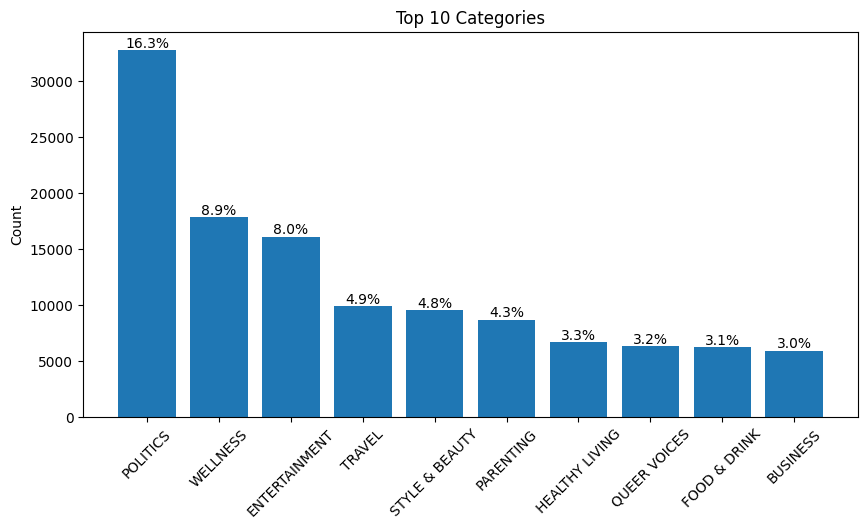

In [56]:
# visualize class imbalance among top 10

class_counts = df["category"].value_counts()

class_percent = (class_counts / class_counts.sum()) * 100

print("\nTop 10 classes (with %):")
for cat in class_counts.head(10).index:
    count = class_counts[cat]
    pct = class_percent[cat]
    print(f"{cat}: {count} ({pct:.2f}%)")

print("\nTotal number of classes:", df["category"].nunique())

top10 = class_counts.head(10)
top10_pct = class_percent.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10.index, top10.values)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = top10_pct.iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{pct:.1f}%", ha='center', va='bottom')

plt.title("Top 10 Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [57]:
# (5) Create reproducible splits

RANDOM_SEED = 42

# train 80/20 split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=RANDOM_SEED)

# set validation and test set to 10%
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=RANDOM_SEED)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Split sizes:
Train: 160148
Validation: 20018
Test: 20019


In [58]:
# (6) Document your pipeline

# convert splits to hugging face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# apply tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

# set pytorch
columns_to_return = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns_to_return)
val_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

Map:   0%|          | 0/160148 [00:00<?, ? examples/s]

Map:   0%|          | 0/20018 [00:00<?, ? examples/s]

Map:   0%|          | 0/20019 [00:00<?, ? examples/s]

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**

We loaded the dataset using HuggingFace datasets library. We removed empty rows, short rows of length less than 20, and duplicate rows. We changed all values to lower case and trimmed white spaces. We also encoded the categorical labels.


2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**

We tokenized the data to convert the text data into numerical representations. The tokenizatoin generated input_ids and attention_mask for each row, allowing the model to process text inputs. The tokenized datasets were then converted to HuggingFace dataset objects and formatted for PyTorch by using the input_ids, attention_mask, and label. Standardization was used to ensure that all inputs were in a consistent format suitable for the batch processing and model training.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**
The data was split into training, validation, and test sets using 80/10/10 ratio and was done in 2 steps using train_test_split. We used random seed of 42 to ensure reproducibility.  We applied stratification based on the label column to preserve the class distribution across all splits.



4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**

*   List item //
Label Counts:
Label 0: 1505
Label 1: 1338
Label 2: 4522
Label 3: 5928
Label 4: 1143
Label 5: 5094
Label 6: 3400
Label 7: 1029
Label 8: 3422
Label 9: 1003
Label 10: 16048
Label 11: 1322
Label 12: 1394
Label 13: 6225
Label 14: 1397
Label 15: 2613
Label 16: 6667
Label 17: 4161
Label 18: 3456
Label 19: 1129
Label 20: 2811
Label 21: 1706
Label 22: 8649
Label 23: 3896
Label 24: 32707
Label 25: 6310
Label 26: 2546
Label 27: 2177
Label 28: 4880
Label 29: 2246
Label 30: 9511
Label 31: 2092
Label 32: 2033
Label 33: 3664
Label 34: 9877
Label 35: 3651
Label 36: 2665
Label 37: 17821
Label 38: 3400
Label 39: 2176
Label 40: 2571
*   List item //
Label Distribution (%):
Label 0: 0.75%
Label 1: 0.67%
Label 2: 2.26%
Label 3: 2.96%
Label 4: 0.57%
Label 5: 2.54%
Label 6: 1.70%
Label 7: 0.51%
Label 8: 1.71%
Label 9: 0.50%
Label 10: 8.02%
Label 11: 0.66%
Label 12: 0.70%
Label 13: 3.11%
Label 14: 0.70%
Label 15: 1.31%
Label 16: 3.33%
Label 17: 2.08%
Label 18: 1.73%
Label 19: 0.56%
Label 20: 1.40%
Label 21: 0.85%
Label 22: 4.32%
Label 23: 1.95%
Label 24: 16.34%
Label 25: 3.15%
Label 26: 1.27%
Label 27: 1.09%
Label 28: 2.44%
Label 29: 1.12%
Label 30: 4.75%
Label 31: 1.05%
Label 32: 1.02%
Label 33: 1.83%
Label 34: 4.93%
Label 35: 1.82%
Label 36: 1.33%
Label 37: 8.90%
Label 38: 1.70%
Label 39: 1.09%
Label 40: 1.28%


There is a clear class imbalance where some classes had significantly more samples than the others. To address this issue, class weights were computed and applied during the training process to ensure that the underrepresented classes were given higher importance, to improve overal model fairness and performance.



## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [59]:
# Your code here; add as many cells as you need but make it clear what the structure is.

# create data loaders

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [60]:
# (1) Construct a Baseline Model

class BaselineClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)                 # (B, L, D)
        x = x.mean(dim=1)                             # global average pooling
        logits = self.fc(x)                           # (B, num_classes)
        return logits

vocab_size = tokenizer.vocab_size
embed_dim = 128
num_classes = len(label_2)

baseline_model = BaselineClassifier(vocab_size, embed_dim, num_classes)

In [61]:
# convert class weights into a tensor

weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float)

weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float)

In [62]:
# (2) Compile the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model.to(device)

optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

# using class weights to address class imbalance
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [63]:
# (3) Train and Validate

EPOCHS = 20
patience = 5 # early stopping

best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time()

for epoch in range(EPOCHS):
    baseline_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = baseline_model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation
    baseline_model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = baseline_model(input_ids)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = baseline_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

end_time = time()
print(f"\nTraining time: {(end_time - start_time):.2f} seconds")

Epoch 1:
Train Loss: 3.1301, Train Acc: 0.2881
Val Loss:   2.5943, Val Acc:   0.4081
Epoch 2:
Train Loss: 2.2303, Train Acc: 0.4726
Val Loss:   2.0671, Val Acc:   0.4861
Epoch 3:
Train Loss: 1.7859, Train Acc: 0.5375
Val Loss:   1.8390, Val Acc:   0.5238
Epoch 4:
Train Loss: 1.5342, Train Acc: 0.5773
Val Loss:   1.7358, Val Acc:   0.5379
Epoch 5:
Train Loss: 1.3579, Train Acc: 0.6075
Val Loss:   1.6946, Val Acc:   0.5481
Epoch 6:
Train Loss: 1.2156, Train Acc: 0.6335
Val Loss:   1.6706, Val Acc:   0.5605
Epoch 7:
Train Loss: 1.0947, Train Acc: 0.6574
Val Loss:   1.6718, Val Acc:   0.5600
Epoch 8:
Train Loss: 0.9850, Train Acc: 0.6800
Val Loss:   1.6854, Val Acc:   0.5783
Epoch 9:
Train Loss: 0.8901, Train Acc: 0.7012
Val Loss:   1.7077, Val Acc:   0.5720
Epoch 10:
Train Loss: 0.8020, Train Acc: 0.7210
Val Loss:   1.7449, Val Acc:   0.5788
Epoch 11:
Train Loss: 0.7207, Train Acc: 0.7402
Val Loss:   1.7869, Val Acc:   0.5798
Early stopping triggered.

Training time: 186.49 seconds


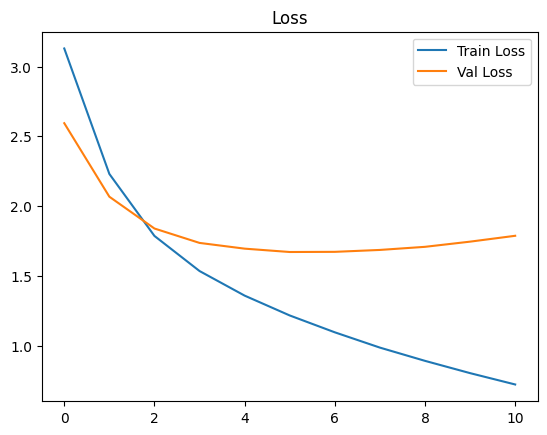

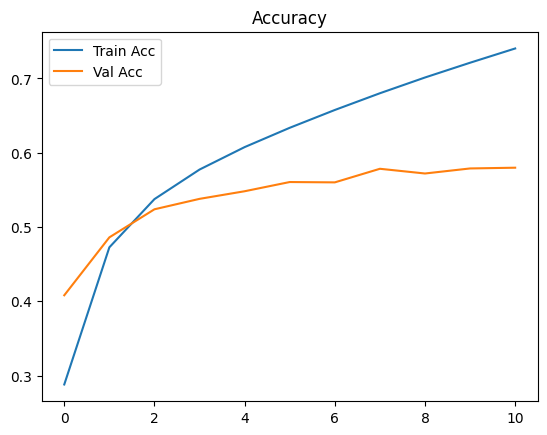

In [64]:
# (4) Visualize Results

# Loss
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

# Accuracy
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

In [66]:
# (5) Report baseline performance

baseline_model.load_state_dict(best_model_state)

baseline_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = baseline_model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5706


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

We built the baseline model using an emedding layer followed by global average pooling and a linear classification layer. This converts each text into an average representation of its word embeddings. This structure suits the dataset because it can train quickly and provide a strong baseline for comparison with more complex models.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

During training, we observed that the training accuracy steadily increased from 0.29 to 0.76 while the training loss consistently decreased. This shows that the model was learning effectly. HOwever ,the validation accuracy improved early and then plateaued, while the alidation loss began to increase after around epic 6-7. This divergence betweeen the training and validation perforamnce suggests that the model started to oerfit which is why the early stopping was triggered.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

The baseline model achieved a validation accuracy of approximately 0.58 at its best epoch and a test accuracy of 0.5672. This performance shows that the dataset is pretty difficult to model and its probably because of the large number of classes and significant class imbalance.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

The main limitations of our baseline model is that it ignores word order by averaging embeddings which limits its ability to capture contextual meaning. To imrpove performance, we could add sequence base models like LSTM as well as regularization techniques like drop out.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [67]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(0.3)   # adding drop out
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [68]:
vocab_size = tokenizer.vocab_size
embed_dim = 128
hidden_dim = 128
num_classes = len(label_2)

LSTM_model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes).to(device)

optimizer = torch.optim.Adam(LSTM_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [69]:
train_accs = []
val_accs = []

EPOCHS = 10

for epoch in range(EPOCHS):
    LSTM_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = LSTM_model(input_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    LSTM_model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = LSTM_model(input_ids)
            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Train Acc: 0.1023 | Val Acc: 0.2083
Epoch 2 | Train Acc: 0.3153 | Val Acc: 0.4261
Epoch 3 | Train Acc: 0.4540 | Val Acc: 0.4885
Epoch 4 | Train Acc: 0.5197 | Val Acc: 0.5098
Epoch 5 | Train Acc: 0.5637 | Val Acc: 0.5176
Epoch 6 | Train Acc: 0.6002 | Val Acc: 0.5157
Epoch 7 | Train Acc: 0.6333 | Val Acc: 0.5287
Epoch 8 | Train Acc: 0.6641 | Val Acc: 0.5222
Epoch 9 | Train Acc: 0.6888 | Val Acc: 0.5316
Epoch 10 | Train Acc: 0.7113 | Val Acc: 0.5307


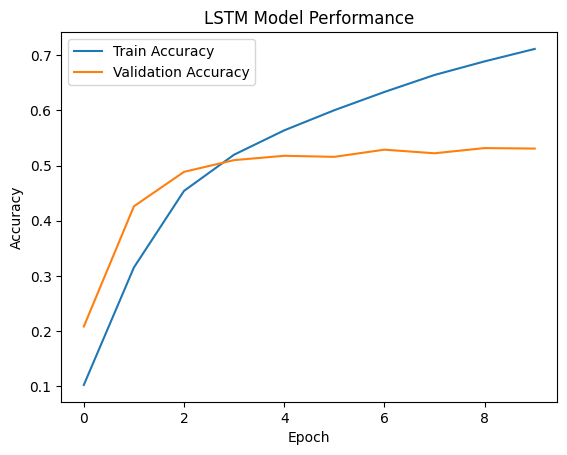

In [70]:
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Performance")
plt.legend()
plt.show()

In [71]:
LSTM_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = LSTM_model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Custom Model Test Accuracy:", correct / total)

Custom Model Test Accuracy: 0.5341925171087467


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

We modified the baseline by replacing the global average poolling with an LSTM layer to capture the sequential dependencies in the text. We also addded a drop out layer to reduce overfitting and to improve generalization. These changes were motivated by the limitation in the baseline model as mentioned in question 2.4.


2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

The custom model acheived a test accuracy of 0.5410 which is slightly lower than the baseline model of 0.5672. This model learned meaningful patterns but it did not improve the performance overall. This suggests that a more complex model does not necessarily improve generalization for this dataset.


3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

\3.3. **Your answer here:**

What worked is that the LSTM helped capture sequential information but it most likely introduced overfitting due to the increased model complexity. What did not work is that the model struggled to generalize compared to the baseline model. This shows that more complex models may not always provide better results than the simpler models without proper tuning.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

This experiment showed that increasing the model complexity can easily lead to overfitting if it is not controlled. Adding drop out helped, but further tuning may be needed.


## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [72]:
DB_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_2)
).to(device)

optimizer = torch.optim.AdamW(DB_model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [73]:
EPOCHS = 3

train_losses = []
val_losses = []
val_accs = []

start_time = time()

for epoch in range(EPOCHS):
    DB_model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = DB_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}")

    # validation
    DB_model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = DB_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            val_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}\n")

end_time = time()
print(f"Training time: {(end_time - start_time):.2f} seconds")

Epoch 1, Train Loss: 1.3346
Val Loss: 1.0222, Val Acc: 0.6992

Epoch 2, Train Loss: 0.9000
Val Loss: 0.9743, Val Acc: 0.7093

Epoch 3, Train Loss: 0.6985
Val Loss: 0.9938, Val Acc: 0.7101

Training time: 610.49 seconds


In [74]:
DB_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = DB_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.7112742894250462


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

We selected the DistilBERT as the pretrained architecture because it provides a strong contextual representation while being more efficient than the full BERT. This choice makes sense because we are working with text classifcation and it can integrate easily with our tokenization pipeline.

2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

We did full fine tuning by allowing all layers of DistilBERT to update during training with a low learning rate of 2e-5. This helped preserve pretrained knowledge while also adpating the model to our dataaset. We chose this strategy to maximize performance and allow the model to fully learn the task specific patterns.


3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

The pretrained model achieved a alidation accuracy of 0.71 and a test accuracy of 0.7137 which is significantly higher than both the baseline with 0.5672 and the custom LSTM with 0.5410. It also converged quickly and reached a strong performance within 3 epoches. This shows that the transfer learning greatly improved both accuracy and generalization.


4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The DistilBERT model required more training time and higher GPU memory compared to the baseline and the LSTM models. However, it was able to converge much faster in terms of number of epoches and also acheived better performance overall. There is definitely a tradeoff ebtween increased computational cost and gains in accuracy when using the pretained models, but this yields much better results.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

In [75]:
def evaluate_model(model, test_loader, is_bert=False):
    model.eval()
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            if is_bert:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
            else:
                logits = model(input_ids)

            preds = torch.argmax(logits, dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average="macro")

    return acc, f1

In [76]:
baseline_acc, baseline_f1 = evaluate_model(baseline_model, test_loader, is_bert=False)
lstm_acc, lstm_f1 = evaluate_model(LSTM_model, test_loader, is_bert=False)
bert_acc, bert_f1 = evaluate_model(DB_model, test_loader, is_bert=True)

In [79]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(baseline_model)
lstm_params = count_parameters(LSTM_model)
bert_params = count_parameters(DB_model)

In [80]:
results = pd.DataFrame({
    "Model": ["Baseline", "LSTM", "DistilBERT"],
    "Accuracy": [baseline_acc, lstm_acc, bert_acc],
    "F1 Score": [baseline_f1, lstm_f1, bert_f1],
    "Training Time (s)": [195, 200, 610],  # replace if you want exact
    "Parameters": [baseline_params, lstm_params, bert_params]
})

print(results)

        Model  Accuracy  F1 Score  Training Time (s)  Parameters
0    Baseline  0.570558  0.493210                195     3912105
1        LSTM  0.534193  0.454128                200     4044201
2  DistilBERT  0.711274  0.617280                610    66985001


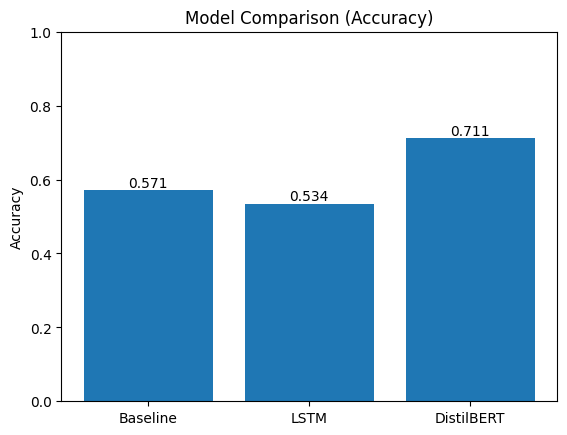

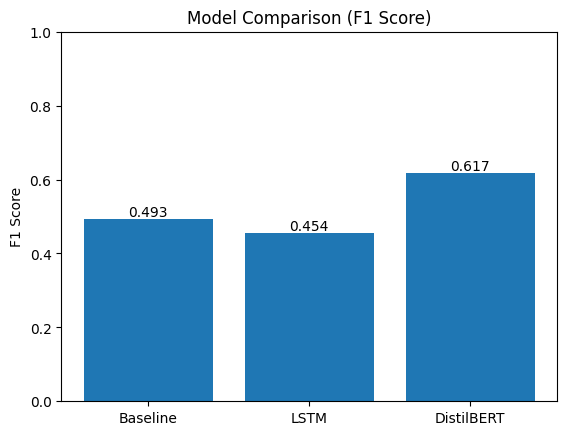

In [93]:
# accuracy plot
plt.figure()
bars = plt.bar(results["Model"], results["Accuracy"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


# F1 Score plot
plt.figure()
bars = plt.bar(results["Model"], results["F1 Score"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

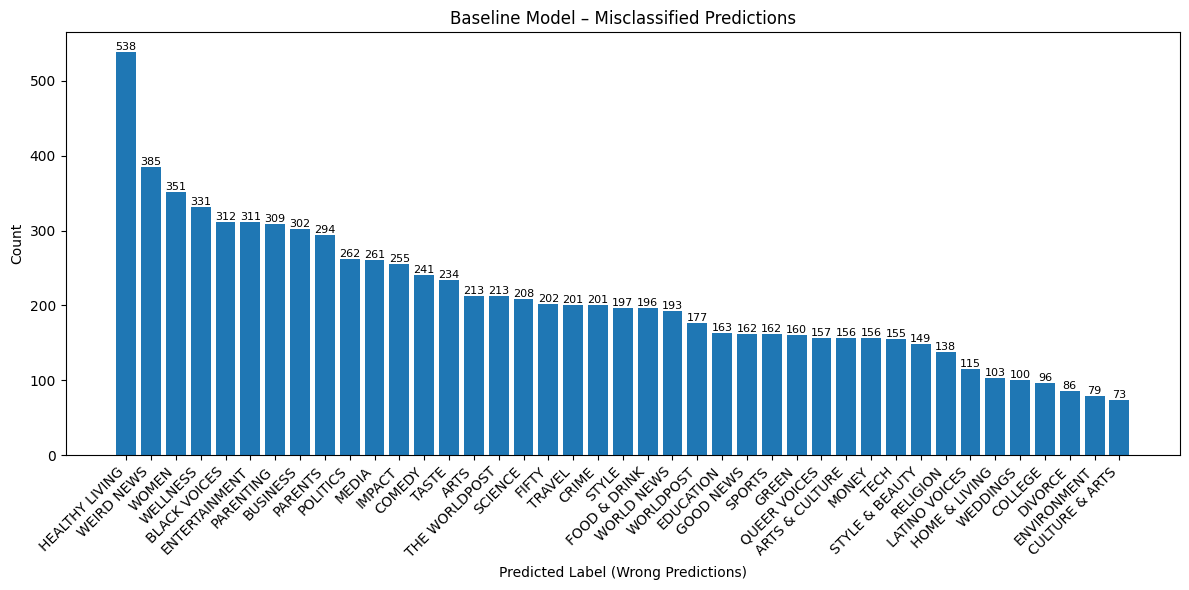

In [105]:
misclassified_baseline = []

baseline_model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = baseline_model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_baseline.append((
                    input_ids[i].cpu(),
                    labels[i].item(),
                    preds[i].item()
                ))

pred_counts = Counter()

for _, true, pred in misclassified_baseline:
    pred_counts[pred] += 1

sorted_counts = sorted(pred_counts.items(), key=lambda x: x[1], reverse=True)

labels = [label_2_id[p] for p, _ in sorted_counts]
counts = [c for _, c in sorted_counts]

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.title("Baseline Model – Misclassified Predictions")
plt.xlabel("Predicted Label (Wrong Predictions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

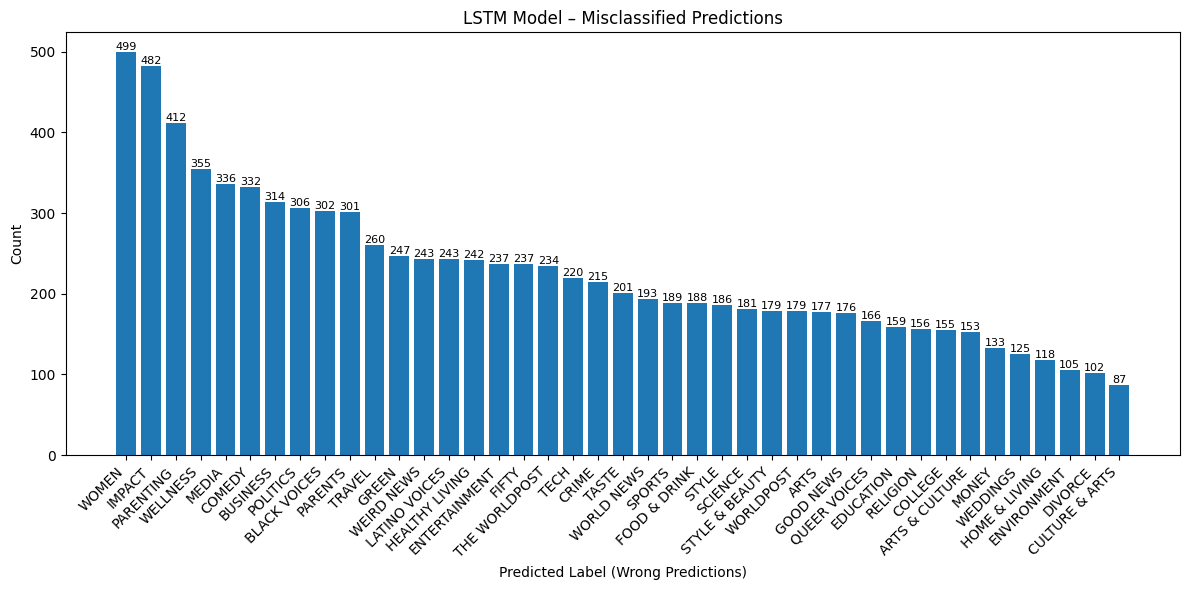

In [106]:
misclassified_lstm = []

LSTM_model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = LSTM_model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_lstm.append((
                    input_ids[i].cpu(),
                    labels[i].item(),
                    preds[i].item()
                ))

pred_counts = Counter()

for _, true, pred in misclassified_lstm:
    pred_counts[pred] += 1

sorted_counts = sorted(pred_counts.items(), key=lambda x: x[1], reverse=True)

labels = [label_2_id[p] for p, _ in sorted_counts]
counts = [c for _, c in sorted_counts]

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.title("LSTM Model – Misclassified Predictions")
plt.xlabel("Predicted Label (Wrong Predictions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [97]:

# looking for classes that were challenging in DB model

misclassified = []

DB_model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        attention_mask = batch["attention_mask"].to(device)
        outputs = DB_model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified.append((
                    input_ids[i].cpu(),
                    labels[i].item(),
                    preds[i].item()
                ))


In [101]:
label_2_id = {i: label for label, i in label_2.items()}

for i in range(5): # show 5 examples of misclassified rows
    tokens, true_label, pred_label = misclassified[i]

    text = tokenizer.decode(tokens, skip_special_tokens=True)

    print("TEXT:", text)
    print("TRUE:", label_2_id[true_label])
    print("PRED:", label_2_id[pred_label])
    print("-"*50)

TEXT: use the good stuff [ sep ] i told her that when my husband left, he didn ' t ask for anything. not a single photograph. not any artwork the kids had made. he wanted nothing, not a single remnant nor reminder of our 15 years together.
TRUE: DIVORCE
PRED: PARENTING
--------------------------------------------------
TEXT: inside the world of an event planner : behind the scenes at tracy taylor ward design [ sep ] how do you figure out who to contact and what you need to find out about them? these are the questions that inspired me to interview and write about a number of event planners.
TRUE: WEDDINGS
PRED: HOME & LIVING
--------------------------------------------------
TEXT: boston marathon bombings : it ' s different this time [ sep ] the bombings caused a whole host of memories to come flooding back and i found myself reliving the confusion, the concern, the sadness, and of course, the fear, all over again. yet, this
TRUE: PARENTING
PRED: WELLNESS
-------------------------------

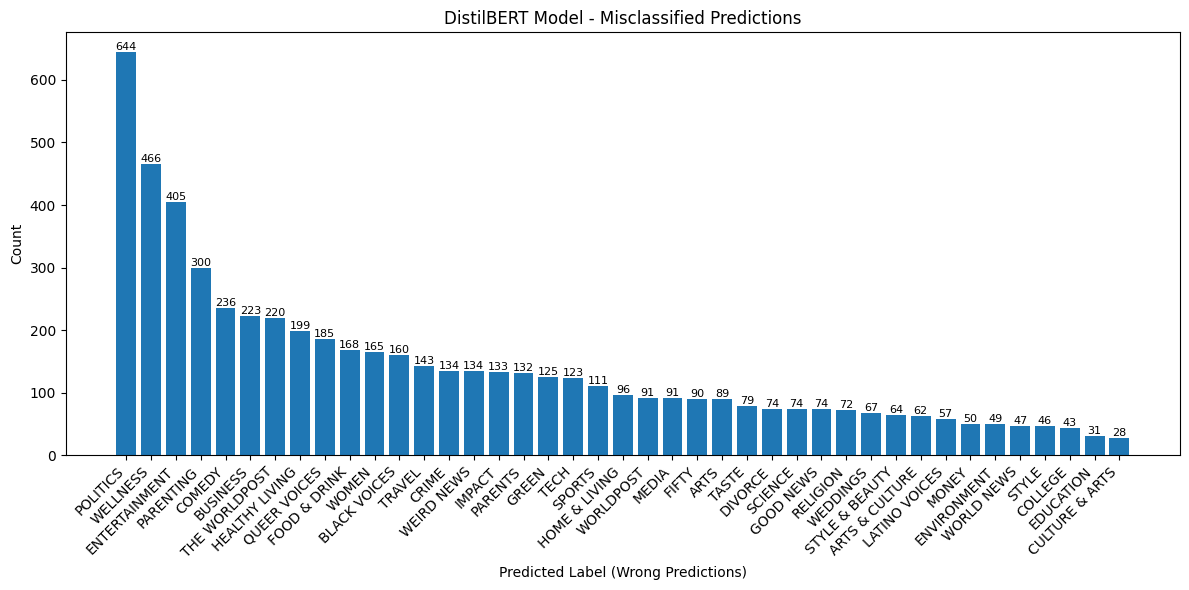

In [107]:

# plotting misclassfied labels from DB model
pred_counts = Counter()

for _, true, pred in misclassified:
    pred_counts[pred] += 1

sorted_counts = sorted(pred_counts.items(), key=lambda x: x[1], reverse=True)

labels = [label_2_id[p] for p, _ in sorted_counts]
counts = [c for _, c in sorted_counts]

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.title("DistilBERT Model - Misclassified Predictions")
plt.xlabel("Predicted Label (Wrong Predictions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**


The DistilBERT omdel acheived teh best overall results with an accuracy of 0.711 and a F1 score of 0.617. It was able to perform better than the baseline and LSTM model because it leveraged pretrained contextual represenations which allowed the model to better understand the text.

2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

The baseline model was the most efficient witht he smallest size and fastest training time but it had lower performance. The LSTM model increased complexity, but it did not improve accuracy which suggested diminishing returns without proper tuning. The DistilBERT model required a lot more paramters and training time but it did deliver much higher accuracy and better generalization. The performance of these models shows the trade off between computational cost and performance.

3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**


All models struggled with less frequent classes due to class imbalance in the dataset. The baseline and the LSTM models had more difficulty differing between similar categories which lead to more misclassifications. DistilBERT reduced these misclassifications but it still showed confusion among the closely related classes.


In milestone 1, we examined that the potentially confusing categories were POLITICS vs WORLD NEWS, WELLNESS vs HEALTHY LIVING, and STYLE vs STYLE & BEAUTY.

The Baseline Model - Misclassified Predictions bar chart shows that HEALTHY LIVING and WELLNESS were among the top 5 misclassified labels.

The LSTM - Misclassified Predictions bar chart shows that WOMEN, IMPACT, and PARENTING were the top 3 misclassifed labels which we did not exepct from our eda.

The DistilBERT - Misclassified Predictions bar chart shows that POLITICS and WELNESS were the top 2 misclassifed labels which aligns with our suspicions from milstone 1.

These examples remained challenging for the models.

4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**

Based on these findings, I would choose the DistilBERT model to go forward with. To improve the model, we would explore additional fine tuning and hyperparameter tuning. I would also consider improving class balance or using data augmentation to reduce errors on the minority class.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

We used generative AI tools to debug code and also assist with generating plotting and graphing functions.